In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix
import plotly.express as px
import time


In [3]:
digits=load_digits()

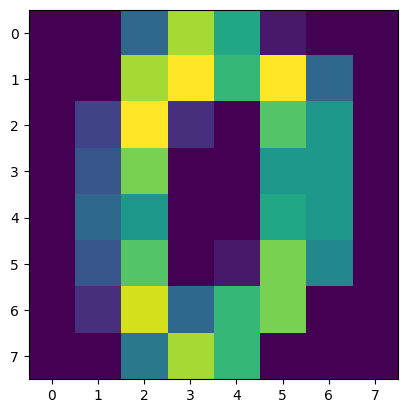

In [4]:
plt.imshow(digits.images[0])

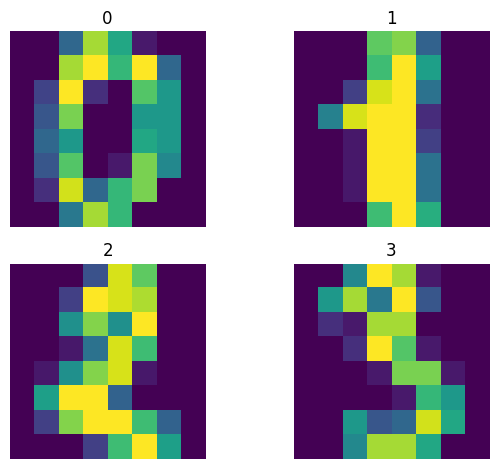

In [5]:
fig,axes=plt.subplots(2,2)
axes[0,0].imshow(digits.images[0])
axes[0,0].set_title(digits.target[0])
axes[0,1].imshow(digits.images[1])
axes[0,1].set_title(digits.target[1])
axes[1,0].imshow(digits.images[2])
axes[1,0].set_title(digits.target[2])
axes[1,1].imshow(digits.images[3])
axes[1,1].set_title(digits.target[3])
# remove axis ticks
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
x=digits.data
y=digits.target

In [7]:
x.shape

(1797, 64)

In [8]:
# data standardization
X_std=StandardScaler().fit_transform(x)
X_std

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

<Axes: >

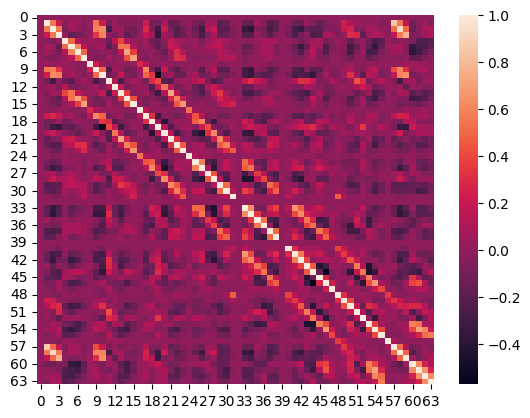

In [9]:
# covariance matrix
cov_mat=np.cov(X_std.T)
sns.heatmap(cov_mat)

In [10]:
# Eigenvalues and Eigenvector
eig_vals,eig_vecs=np.linalg.eigh(cov_mat)
print(eig_vecs.shape)
np.round(eig_vals,4)

(64, 64)


array([0.    , 0.    , 0.    , 0.0504, 0.0633, 0.0764, 0.0825, 0.0902,
       0.0984, 0.1025, 0.1119, 0.1193, 0.1243, 0.1332, 0.1431, 0.1582,
       0.1688, 0.1761, 0.1898, 0.2001, 0.208 , 0.2176, 0.2424, 0.2478,
       0.2583, 0.2769, 0.2941, 0.3196, 0.3486, 0.3609, 0.3911, 0.3991,
       0.4223, 0.4429, 0.4556, 0.4869, 0.5106, 0.5267, 0.5765, 0.5953,
       0.6455, 0.7116, 0.7763, 0.8227, 0.9089, 0.9744, 0.9998, 1.0837,
       1.1683, 1.3215, 1.3593, 1.3887, 1.5729, 1.6978, 1.7895, 1.8299,
       2.0687, 2.406 , 2.572 , 2.9663, 3.9662, 5.154 , 5.8355, 7.3448])

In [11]:
# create a list of eigenvalues and eigenvectors
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]


# sort from high to low
eig_pairs.sort(key=lambda x:x[0] , reverse=True)

# calculation of explain variance from the eigen values
tot=sum(eig_vals)
var_exp=[(i/tot)*100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp=np.cumsum(var_exp)# cumulative explained variance 
cum_var_exp


array([ 12.0339161 ,  21.5949705 ,  30.03938539,  36.5377933 ,
        41.39794818,  45.61206805,  49.55415085,  52.94353177,
        55.94175279,  58.87375534,  61.6555608 ,  64.23261589,
        66.50791921,  68.73509895,  70.90032838,  72.81449499,
        74.59004207,  76.22811135,  77.82457152,  79.3137627 ,
        80.66173227,  81.93366364,  83.09950099,  84.15714759,
        85.13246353,  86.07702252,  86.94003635,  87.77667921,
        88.57437245,  89.32084382,  90.04642598,  90.73833722,
        91.39224576,  92.03303833,  92.62442244,  93.19558485,
        93.71922165,  94.20102924,  94.6547485 ,  95.07791125,
        95.48396432,  95.88104913,  96.23754243,  96.57832961,
        96.90616495,  97.21719696,  97.50577225,  97.78226151,
        98.04143645,  98.27591946,  98.49417632,  98.69777395,
        98.89328638,  99.07660488,  99.24455127,  99.40578733,
        99.55355002,  99.68866843,  99.81376918,  99.91746491,
       100.        , 100.        , 100.        , 100.  

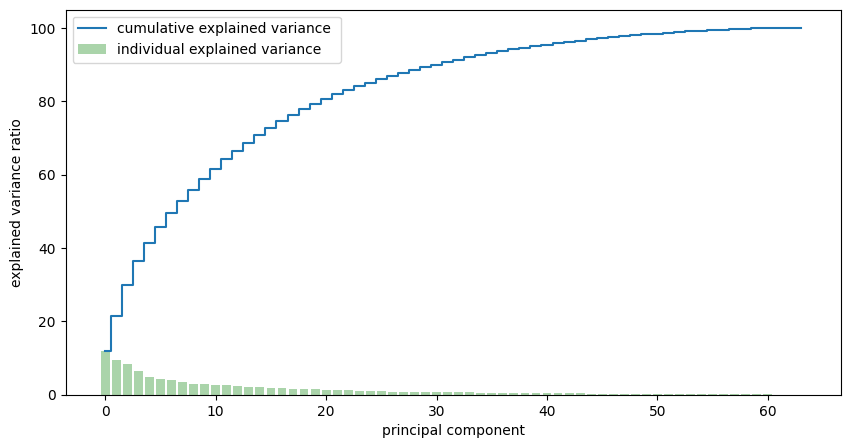

In [12]:
plt.figure(figsize=(10,5))
plt.bar(range(len(var_exp)),var_exp , alpha=0.333 , align='center' ,label='individual explained variance',color='green')
plt.step(range(len(cum_var_exp)) , cum_var_exp , where='mid' , label='cumulative explained variance ')
plt.ylabel('explained variance ratio')
plt.xlabel('principal component')
plt.legend(loc='best')

In [13]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(X_std,y,random_state=42)

In [14]:
pca=PCA(n_components=20)
pca_x_train=pca.fit_transform(x_train)
pca_x_test=pca.fit_transform(x_test)

In [15]:
dt=DecisionTreeClassifier(random_state=42).fit(x_train,y_train)
pca_dt=DecisionTreeClassifier(random_state=42).fit(pca_x_train,y_train)

In [16]:
y_pred = dt.predict(x_test)
pca_y_pred = pca_dt.predict(pca_x_test)


In [17]:
print("accuracy score :", accuracy_score(y_pred,y_test))
print("accuracy score :", accuracy_score(pca_y_pred,y_test))

accuracy score : 0.8533333333333334
accuracy score : 0.11555555555555555


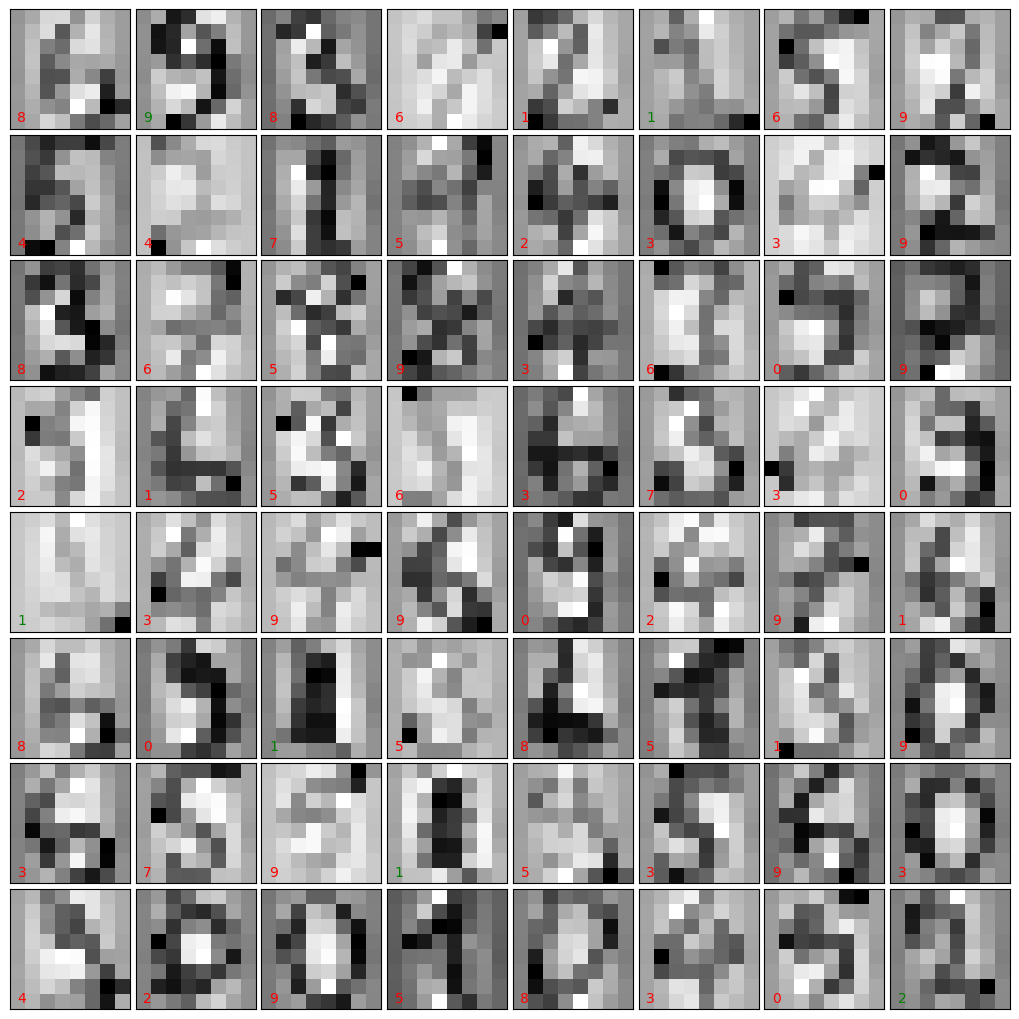

In [18]:
# plot the prediction
fig=plt.figure(figsize=(10,10))
fig.subplots_adjust(left=0,right=1,bottom=0,top=1 ,hspace=0.05 , wspace=0.05)
predicted=pca_y_pred
expected=y_test
# plot the digit : each image is 8*8 pixels
for i in range(64):
    ax=fig.add_subplot(8,8,i+1,xticks=[],yticks=[])
    ax.imshow(x_test.reshape(-1,8,8)[i],cmap=plt.cm.binary,interpolation='nearest')
    # label the image with the target value
    if predicted[i] == expected[i]:
        ax.text(0,7,str(predicted[i]),color='green')
    else:
        ax.text(0,7,str(predicted[i]),color='red')
    

### PCA HANDSON 

***step 1 : Standardization***

***step 2 : Co-variance matrix - negative , positive or zero***

***step 3 : Compute eigen values and eigen vectors*** 
     
      the change in direction after the matrix transformation 
      or multiplication.(no change for doing transformation with identity matrix)

      the change of certain values is eigen values(no change for the same above )
      - how much the image is stretched or shrink is the eigen value.

***step 4 : sort eigen values***
 
 pca_1= high variance
 
 pca_2= low variance

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer


In [20]:
data=load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [21]:
# the data is in  dictionary format so we have to convert 
df=pd.DataFrame(data.data , columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [22]:
# there is no target column as the target was in separate list thats why it dont load in above

In [23]:
df['Target']=data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [24]:
# we dont need to perform EDA as sklearn provide a clean data
df.isnull().sum().sum()

np.int64(0)

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
x=df.iloc[:,:-1]
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [27]:
y=df['Target']
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: Target, Length: 569, dtype: int64

In [28]:
# train test split 
from sklearn.model_selection import train_test_split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred=model.predict(x_test)
y_pred

array([ 0.62168355,  0.17803853,  0.27512068,  1.1320503 ,  1.11698318,
       -0.66303713, -0.07355607,  0.44212355,  0.28085763,  0.96360261,
        0.794142  ,  0.33192584,  0.90481757,  0.39666504,  0.9336697 ,
        0.17750175,  0.91013271,  1.19445658,  1.41615414,  0.04464718,
        0.65041677,  0.8752756 , -0.38792384,  1.08061015,  0.96215276,
        0.84678947,  0.99807141,  0.87049439,  0.94386257, -0.16893149,
        1.0238613 ,  1.04190872,  0.81604445,  0.9156589 ,  1.07186427,
        0.84289045,  0.48746626,  0.62375262,  0.25368547,  0.76842229,
        1.15259719,  0.03799193,  0.97126513,  0.99773732,  0.55160057,
        0.65587474,  0.91828081,  1.02580964,  0.80527854,  1.01543748,
        0.20974453, -0.07875586,  0.55842968,  0.59037896,  1.02323689,
        0.78572959,  0.93959678, -0.36416183,  0.55847881,  1.04937824,
        0.94406266, -0.1953921 , -0.35465216,  0.80776979,  0.90208492,
        0.58309865, -0.16982229, -0.15422403,  0.97877451,  0.83

In [31]:
# Convert values > 0.5 to 1, and everything else to 0
y_pred_binary = (y_pred > 0.5).astype(int)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

In [33]:
accuracy_score(y_test,y_pred_binary)

0.956140350877193

In [34]:
print(classification_report(y_test,y_pred_binary))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
sc=StandardScaler()

In [37]:
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [38]:
x_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [39]:
x_test

array([[-0.46649743, -0.13728933, -0.44421138, ..., -0.19435087,
         0.17275669,  0.20372995],
       [ 1.36536344,  0.49866473,  1.30551088, ...,  0.99177862,
        -0.561211  , -1.00838949],
       [ 0.38006578,  0.06921974,  0.40410139, ...,  0.57035018,
        -0.10783139, -0.20629287],
       ...,
       [-0.73547237, -0.99852603, -0.74138839, ..., -0.27741059,
        -0.3820785 , -0.32408328],
       [ 0.02898271,  2.0334026 ,  0.0274851 , ..., -0.49027026,
        -1.60905688, -0.33137507],
       [ 1.87216885,  2.80077153,  1.80354992, ...,  0.7925579 ,
        -0.05868885, -0.09467243]], shape=(114, 30))

In [40]:
from sklearn.decomposition import PCA

In [41]:
pca=PCA(n_components=20)
x_train_pca=pca.fit_transform(x_train)

In [42]:
x_train_pca.shape

(455, 20)

In [43]:
x_test_pca=pca.transform(x_test)
x_test_pca.shape

(114, 20)

In [44]:
model1=LinearRegression()
model1.fit(x_train_pca,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
y_pred1=model1.predict(x_test_pca)
y_pred1

array([ 0.66154715,  0.1684862 ,  0.27855843,  1.00242347,  1.1387871 ,
       -0.57909438, -0.28357435,  0.44484995,  0.51700747,  0.94333094,
        0.79462353,  0.39091177,  0.87727625,  0.51948312,  0.92151131,
        0.10264658,  0.89637657,  1.14893924,  1.37756172,  0.08364449,
        0.64692371,  0.87699786, -0.30331658,  1.10034336,  0.92869674,
        0.88604102,  0.92208629,  0.73458716,  0.97940177, -0.04586491,
        1.00458039,  0.99325626,  0.83028242,  0.9044323 ,  1.01603212,
        0.79003373,  0.45758153,  0.78909356,  0.1651335 ,  0.79909526,
        1.12597399,  0.1245455 ,  0.92660182,  0.97123719,  0.53508039,
        0.73266288,  0.96747118,  0.83199854,  0.83994149,  1.00247735,
        0.18291375, -0.1771843 ,  0.59104544,  0.67033497,  1.09918938,
        0.8472707 ,  0.98567947, -0.48819013,  0.38829531,  1.0033255 ,
        0.88313663, -0.1229961 , -0.26575888,  0.82525581,  0.96248027,
        0.61406008, -0.01914139, -0.17162839,  0.95299501,  0.72

In [46]:
# Convert values > 0.5 to 1, and everything else to 0
y_pred_1binary = (y_pred1 > 0.5).astype(int)

In [47]:
accuracy_score(y_test,y_pred_1binary)


0.9736842105263158

In [48]:
pca.explained_variance_ratio_

array([0.43502782, 0.19500007, 0.09781519, 0.06486409, 0.05253378,
       0.041128  , 0.0223559 , 0.01647952, 0.01380052, 0.01205262,
       0.01056565, 0.00883488, 0.00772384, 0.00531689, 0.00290036,
       0.00274864, 0.00202121, 0.00181312, 0.00163703, 0.00103921])

In [49]:
pca.components_ # eigen vector( dont need to calculate as pca function perform all) 

array([[ 2.16014846e-01,  1.01699596e-01,  2.25181465e-01,
         2.18534830e-01,  1.48981569e-01,  2.40835871e-01,
         2.59499690e-01,  2.63324252e-01,  1.46217348e-01,
         6.57406649e-02,  2.03918546e-01,  2.34543987e-02,
         2.09023919e-01,  1.99502970e-01,  2.15718507e-02,
         1.65762530e-01,  1.49054410e-01,  1.82429814e-01,
         4.76642673e-02,  9.87533276e-02,  2.26391948e-01,
         1.05122879e-01,  2.36126297e-01,  2.24215789e-01,
         1.32347855e-01,  2.11297039e-01,  2.29556005e-01,
         2.52917161e-01,  1.27240897e-01,  1.32340793e-01],
       [-2.40040164e-01, -5.12630139e-02, -2.22160786e-01,
        -2.36489281e-01,  1.69316336e-01,  1.50134402e-01,
         6.40373456e-02, -3.96395631e-02,  1.83279546e-01,
         3.61447295e-01, -1.08859253e-01,  9.69510543e-02,
        -9.16036710e-02, -1.53645976e-01,  1.94465623e-01,
         2.37907034e-01,  2.07841771e-01,  1.43048104e-01,
         1.74509277e-01,  2.81101891e-01, -2.24547535e-

In [50]:
# adding previous features to new feature to get the percentage of the specific data comprises from total data
cum_sum=np.cumsum(pca.explained_variance_ratio_)

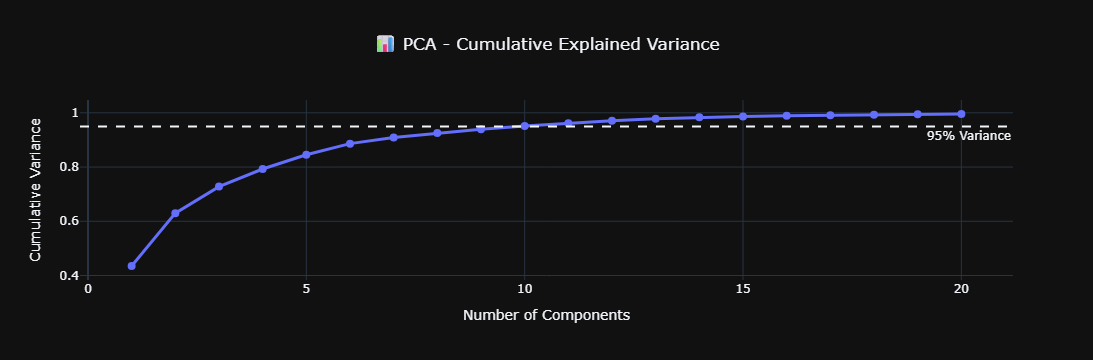

In [51]:
import numpy as np
import plotly.graph_objects as go


cum_sum = np.cumsum(pca.explained_variance_ratio_)


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(1, len(cum_sum)+1)),
    y=cum_sum,
    mode='lines+markers',
    name='Cumulative Variance',
    line=dict(width=3),
    marker=dict(size=8)
))

# add threshold line (important insight)
fig.add_hline(y=0.95, line_dash="dash", 
              annotation_text="95% Variance", 
              annotation_position="bottom right")

# layout customization
fig.update_layout(
    title="📊 PCA - Cumulative Explained Variance",
    xaxis_title="Number of Components",
    yaxis_title="Cumulative Variance",
    template="plotly_dark",   # 🔥 modern look
    title_x=0.5,
    hovermode="x unified"
)

fig.show()